In [1]:
import os
# os.environ["HF_HUB_DISABLE_SYMLINKS_WINDOWS"] = "1"
# !pip install timesfm==1.3.0

In [2]:
import sys
import os

TFM_PROJECT_ROOT = r'C:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm'
V1_SOURCE_DIR = os.path.join(TFM_PROJECT_ROOT, 'v1', 'src')

if V1_SOURCE_DIR not in sys.path:
    sys.path.insert(1, V1_SOURCE_DIR)
    print(f"Priority 1 (V1 Source): Añadido {V1_SOURCE_DIR}")

if TFM_PROJECT_ROOT not in sys.path:
    sys.path.append(TFM_PROJECT_ROOT)
    print(f"Priority 2 (Project Root): Añadido {TFM_PROJECT_ROOT}")


try:
    # Python should look now for 'timesfm' package first in V1_SOURCE_DIR
    from timesfm import pytorch_patched_decoder
    from timesfm import TimesFm, TimesFmHparams 
    
    from v1.src.finetuning import finetuning_torch 
    
    print("Modules loaded successfully from v1 folder")

except ImportError as e:
    print(f"Error when loading module: {e}")

Priority 1 (V1 Source): Añadido C:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm\v1\src
Priority 2 (Project Root): Añadido C:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm
 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


c:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\finetune_timesfm_folder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PyTorch TimesFM, likely because python version is 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
Modules loaded successfully from v1 folder


In [3]:
# Load libraries
from utils_folder.data_util import *
from utils_folder.model_util import *
from utils_folder.comp_util import *

import warnings
warnings.filterwarnings("ignore")

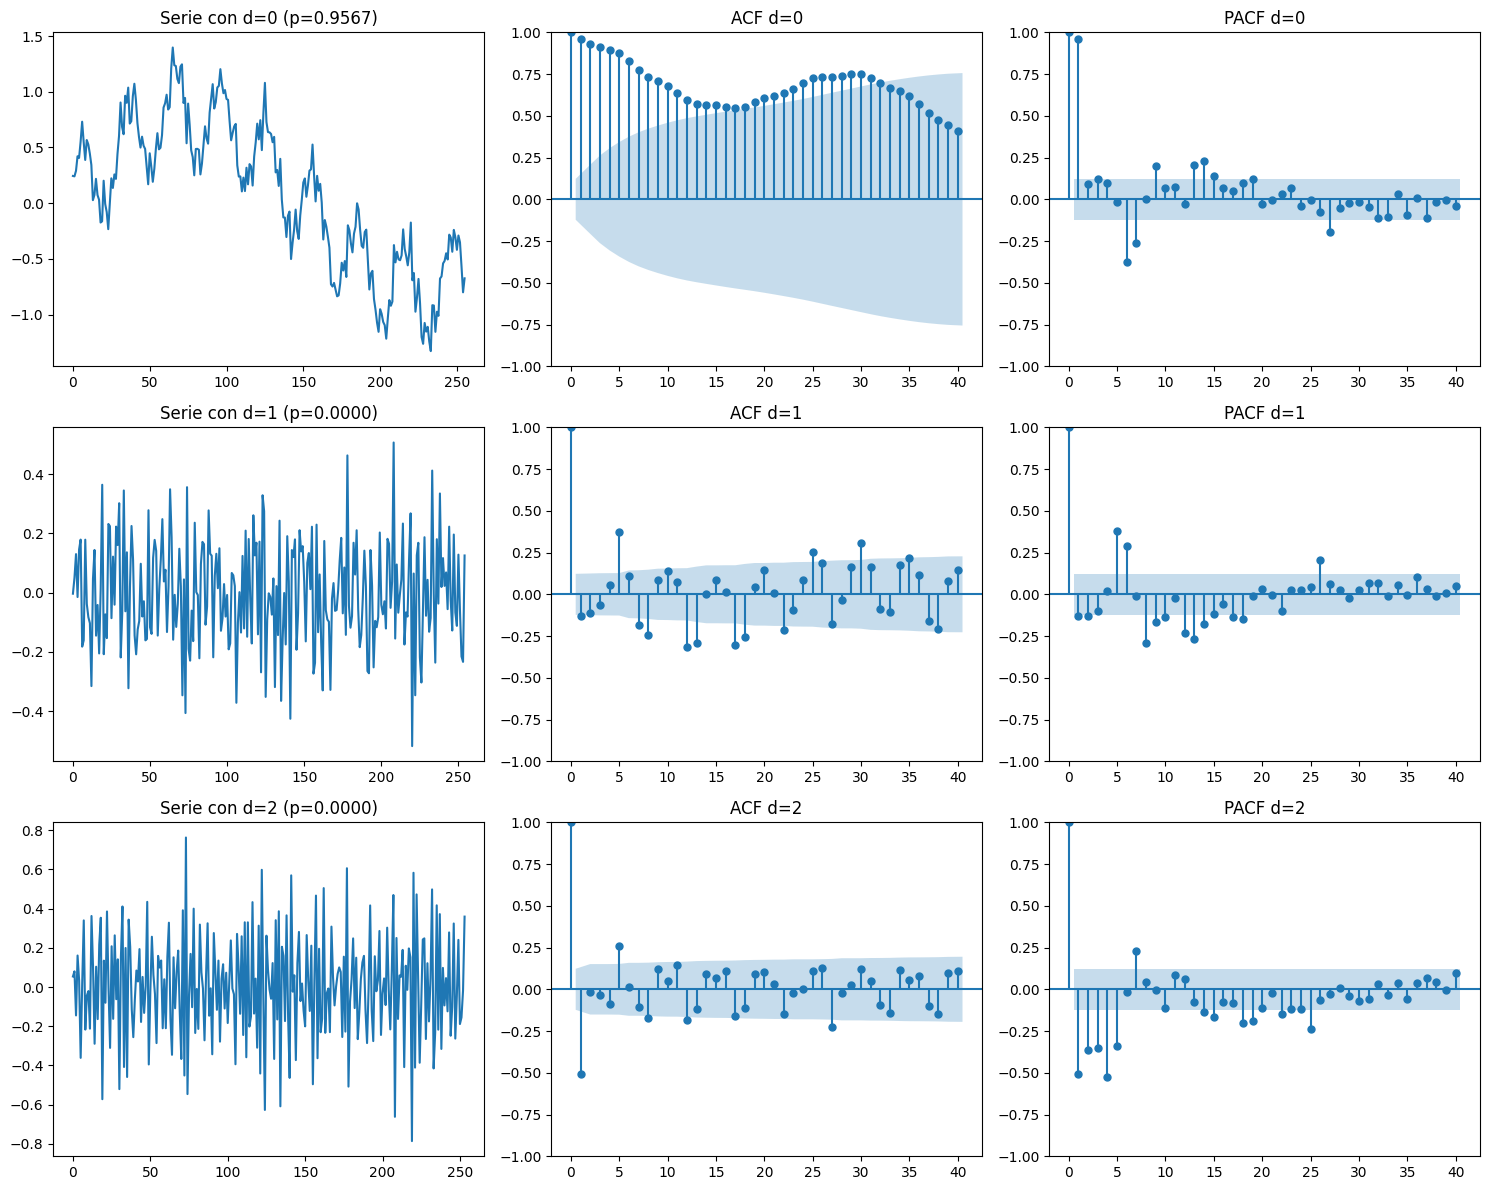

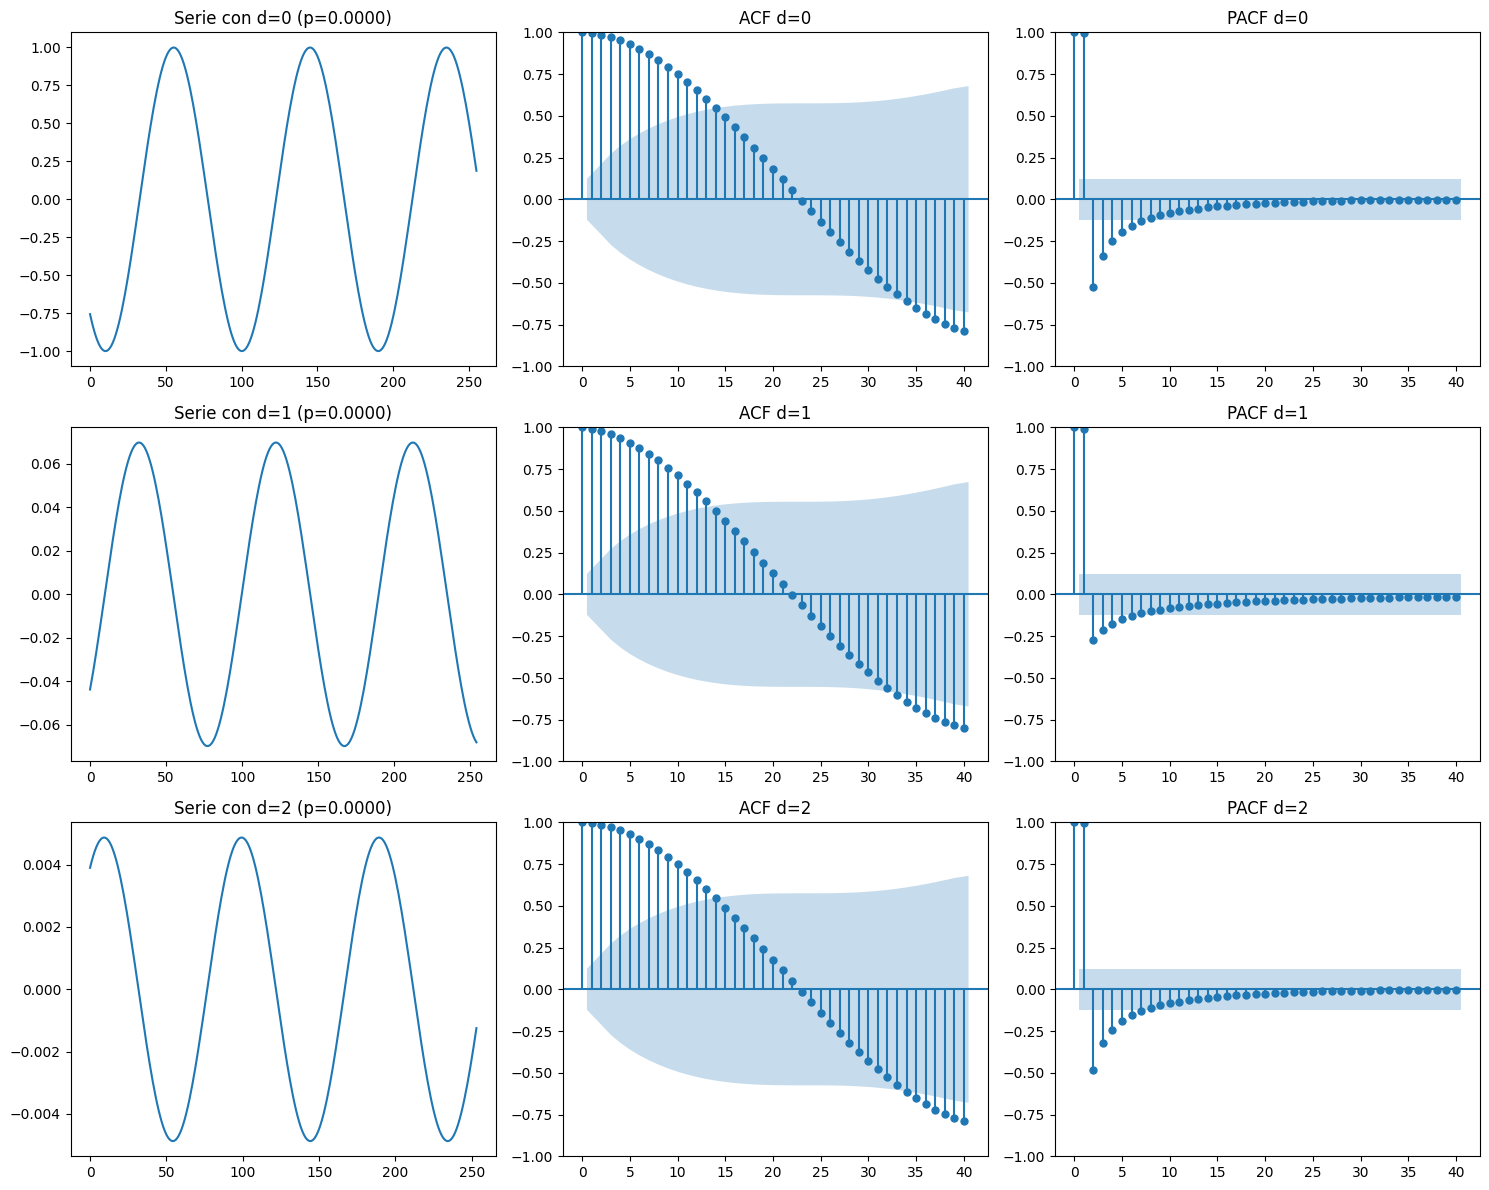

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_sine_differentiation(y_train):
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train)
    results = []
    y_diff = y_train.copy()
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    for d in range(3):
        current_data = y_diff.dropna()
        adf_res = adfuller(current_data)
        p_val = adf_res[1]
        is_stationary = p_val < 0.05
        
        results.append({'d': d, 'p-value': p_val, 'stationary': is_stationary})
        
        # Plot Serie
        axes[d, 0].plot(current_data.values)
        axes[d, 0].set_title(f"Serie con d={d} (p={p_val:.4f})")
        
        # Plot ACF
        plot_acf(current_data, ax=axes[d, 1], lags=40)
        axes[d, 1].set_title(f"ACF d={d}")
        
        # Plot PACF
        plot_pacf(current_data, ax=axes[d, 2], lags=40)
        axes[d, 2].set_title(f"PACF d={d}")
        
        y_diff = y_diff.diff()

    plt.tight_layout()
    plt.show()
    

y_train = sine_dataset(length=256)
analyze_sine_differentiation(y_train)

y_train = sine_dataset(length=256, EASY_DATASET=True)
analyze_sine_differentiation(y_train)

## Last update

In [4]:
import json
from datetime import datetime

def update_experiment_database(all_results, real_data=True, base_filename="metrics_db"):
    """
    Load json and add results.
    all_results: Dict
    """
    date_str = datetime.now().strftime("%Y-%m-%d")
    if real_data:
        filename = f"{base_filename}_{date_str}.json"
    else:
        filename = f"synth_{base_filename}_{date_str}.json"

    existing_data = {}
    if os.path.exists(filename):
        with open(filename, "r") as f:
            try:
                existing_data = json.load(f)
            except json.JSONDecodeError:
                existing_data = {}

    existing_data.update(all_results)

    with open(filename, "w") as f:
        json.dump(existing_data, f, indent=4)
    
    print(f"\n[INFO] Database updated in {filename}")

In [5]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
freq_type = 0
is_real_data = [True]


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:

            res = compare_performance(
                context_len=c,
                horizon_len=h,
                real_data=is_real_data,
                more_models=True,
                freq_type=freq_type
            )

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": res
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"metrics_results_{date_str}.json"
    else:
        file_name = f"synth_metrics_results_{date_str}.json"

    with open(file_name, "w") as f:
        json.dump(results, f, indent=4)

Loading Real Dataset...


[*********************100%***********************]  1 of 1 completed

Created datasets:
- Training samples: 1555
- Test samples: 197
- Using frequency type: 0

Zero-Shot (Pre-trained) Evaluation



Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Zero-Shot RMSE: 2.1631

Fine-Tuning Process


...

Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0

Zero-Shot (Pre-trained) Evaluation



Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Zero-Shot RMSE: 6.3426

Fine-Tuning Process


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Training...

Fine-Tuned Evaluation
Fine-Tuned RMSE: 49.4034

Performance Comparison (RMSE)
Zero-Shot (No Finetuning) RMSE: 6.3426
Fine-Tuned RMSE: 49.4034
Fine-tuning did not improve performance or made it worse (may need more epochs/data).

Evaluating additional models (ARIMA, LSTM, Persistence)...
ARIMA model selected:
Order (p,d,q): (2, 1, 2)

Global Metrics & Time Comparison:
TimesFM ZeroShot: {'RMSE': np.float64(6.342604897094097), 'Inference_Time': 8.786643743515015}
TimesFM Finetuned: {'RMSE': np.float64(49.40336249200773), 'Training_Time': 1794.370329618454, 'Inference_Time': 8.715689659118652}
ARIMA: {'RMSE': 6.176812695694835, 'Inference_Time': 37.50554537773132}
Persistence: {'RMSE': 6.175581932067871, 'Inference_Time': 0.01760721206665039}
LSTM Multi Output: {'RMSE': 15.002224922180176, 'Training_Time': 42.30900454521179, 'Inference_Time': 0.02975749969482422}
LSTM Multi Model: {'RMSE': 14.250043869018555, 'Training_Time': 6517.31433391571, 'Inference_Time': 1.4484636783599

### Plot

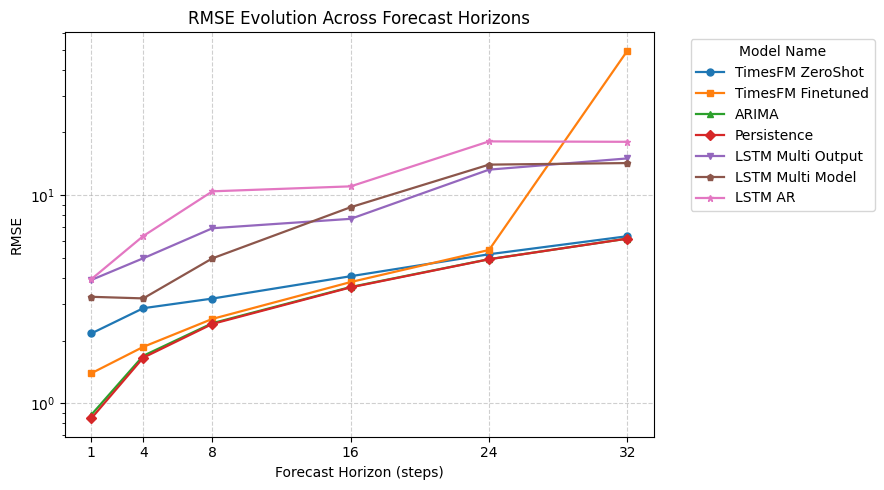

In [8]:
with open("metrics_results_2026-02-02.json", "r") as f:
    data = json.load(f)

all_results = data["experiments"]
filtered_results = [
    exp for exp in all_results
    if exp["context_length"] == 256
]

session_results = {}

for exp in filtered_results:
    h = exp["horizon"]
    session_results[f"horizon_{h}"] = exp["metrics"]

horizon_keys = list(session_results.keys())
horizons = [int(x.split('_')[-1]) for x in horizon_keys]
models = list(session_results[horizon_keys[0]].keys())

rmse_evolution = {model: [session_results[h_key][model]['RMSE'] for h_key in horizon_keys] for model in models}

plt.figure(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', '*']

for i, model in enumerate(models):
    plt.plot(horizons, rmse_evolution[model], 
             marker=markers[i % len(markers)], 
             label=model, 
             linewidth=1.6, 
             markersize=5)

plt.title('RMSE Evolution Across Forecast Horizons')
plt.xlabel('Forecast Horizon (steps)')
plt.ylabel('RMSE')
plt.yscale('log')
plt.xticks(horizons)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('rmse_evolution.png')
plt.show()

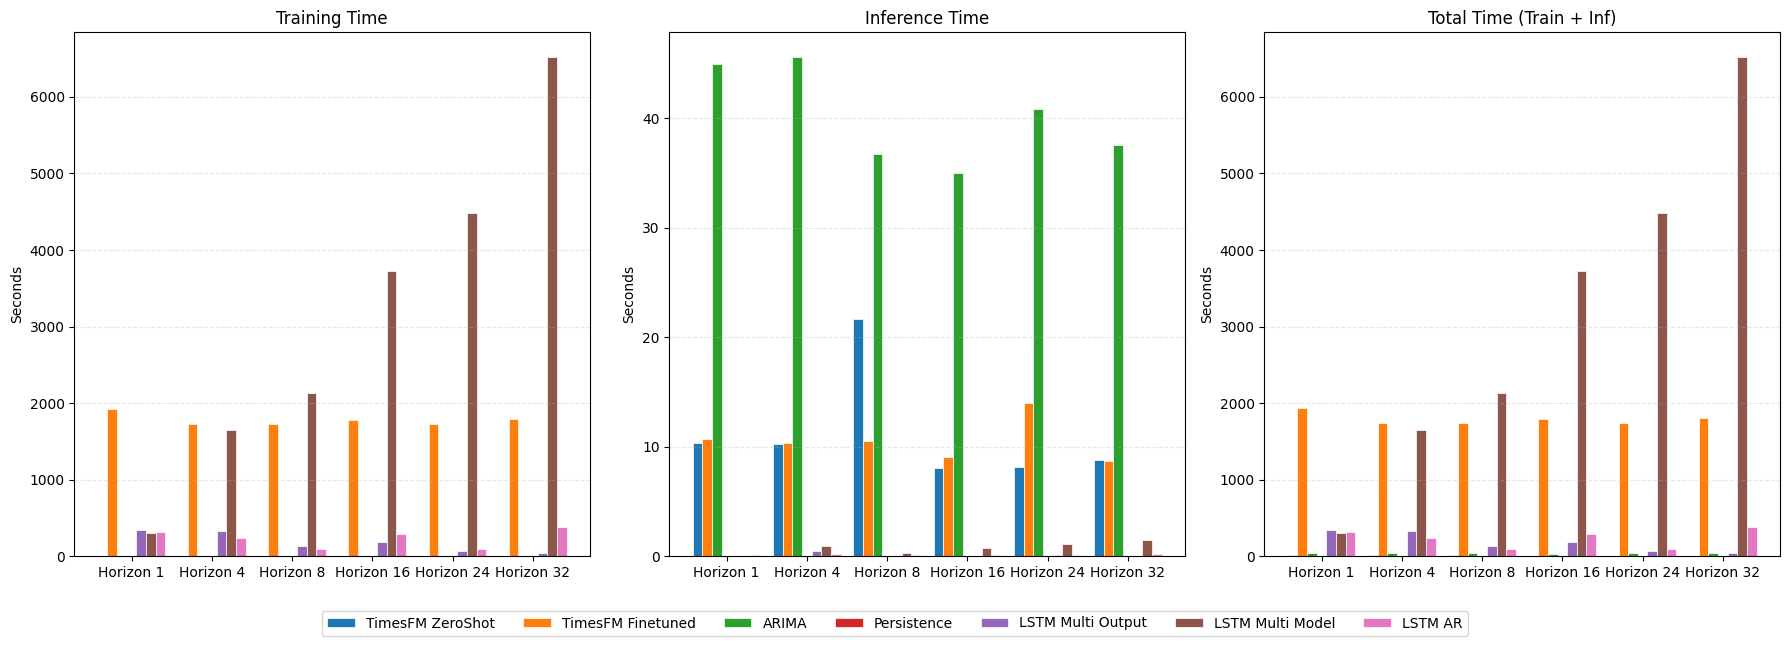

In [9]:
metrics = {
    'Training Time': {m: [session_results[h][m].get('Training_Time', 0) for h in horizon_keys] for m in models},
    'Inference Time': {m: [session_results[h][m].get('Inference_Time', 0) for h in horizon_keys] for m in models},
}
metrics['Total Time'] = {m: [metrics['Training Time'][m][i] + metrics['Inference Time'][m][i] 
                            for i in range(len(horizons))] for m in models}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(horizons))  # Label locations
width = 0.12  # Width of each individual bar

def render_bars(ax, metric_data, title):
    for i, model in enumerate(models):
        # Calculate position for each model's bar within the group
        pos = x + (i - len(models)/2) * width + width/2
        ax.bar(pos, metric_data[model], width, label=model, edgecolor='white', linewidth=0.5)
    
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Horizon {h}' for h in horizons])
    ax.set_ylabel('Seconds')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    # ax.set_yscale('log')


render_bars(axes[0], metrics['Training Time'], 'Training Time')
render_bars(axes[1], metrics['Inference Time'], 'Inference Time')
render_bars(axes[2], metrics['Total Time'], 'Total Time (Train + Inf)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), 
           ncol=len(models))

plt.tight_layout()
plt.show()

In [ ]:
raise Exception("Execution paused. Check your data before continuing.")

### Observations

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
repo_id = "google/timesfm-2.5-200m-pytorch"
hparams = TimesFmHparams(
    backend=device,
    per_core_batch_size=32,
    horizon_len=128,
    num_layers=20,
    use_positional_embedding=False,
    context_len=192,
)
tfm = TimesFm(hparams=hparams,
                checkpoint=TimesFmCheckpoint(huggingface_repo_id=repo_id))

# cannot find model in hugging face folders 

Fetching 4 files: 100%|██████████| 4/4 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\casas\\.cache\\huggingface\\hub\\models--google--timesfm-2.5-200m-pytorch\\snapshots\\1d952420fba87f3c6dee4f240de0f1a0fbc790e3\\torch_model.ckpt'